# 서울 아파트 실거래가 EDA와 평당 단가 기준 만들기

## 작업 순서

1. 데이터가 방대하므로 서울 기준으로만 진행한다.
2. 데이터 파악을 위해 그래프로 시각화한다.
3. 평당 단가를 구해서 가격 판단 기준점을 만든다.
4. 이후 머신러닝 연습 목적과 페르소나를 정의한다.

## 1. 라이브러리 불러오기

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# macOS 한글 폰트 설정: 그래프에서 한글이 깨지는 것을 방지한다.
FONT_PATH = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
font_manager.fontManager.addfont(FONT_PATH)
FONT_NAME = font_manager.FontProperties(fname=FONT_PATH).get_name()

rcParams["font.family"] = FONT_NAME
rcParams["axes.unicode_minus"] = False
rcParams["figure.figsize"] = (10, 5)
rcParams["axes.grid"] = True

print(f"그래프 한글 폰트 설정 완료: {FONT_NAME}")

그래프 한글 폰트 설정 완료: Apple SD Gothic Neo


## 2. 데이터 불러오기

In [2]:
BASE_DIR = Path("..").resolve()
RAW_DIR = BASE_DIR / "data" / "raw" / "21265_transaction_price_data"

train = pd.read_csv(RAW_DIR / "train.csv")
test = pd.read_csv(RAW_DIR / "test.csv")

train.shape, test.shape

((1216553, 13), (5463, 12))

## 3. 서울 데이터만 분리하기

In [3]:
seoul_train = train[train["city"] == "서울특별시"].copy()
seoul_test = test[test["city"] == "서울특별시"].copy()

seoul_train.shape, seoul_test.shape

((742285, 13), (3911, 12))

## 4. 평수와 평당 단가 만들기

- `exclusive_use_area`는 제곱미터 단위다.
- 1평은 약 3.3058제곱미터다.
- 평당 단가 = 거래가 / 평수

In [4]:
seoul_train["pyeong"] = seoul_train["exclusive_use_area"] / 3.3058
seoul_train["price_per_pyeong"] = seoul_train["transaction_real_price"] / seoul_train["pyeong"]
seoul_train["transaction_year"] = seoul_train["transaction_year_month"] // 100
seoul_train["transaction_month"] = seoul_train["transaction_year_month"] % 100
seoul_train["building_age"] = seoul_train["transaction_year"] - seoul_train["year_of_completion"]

# 보기용 단위 변환
# transaction_real_price는 만원 단위로 해석한다. 예: 50,000 = 50,000만 원 = 5억 원
seoul_train["transaction_price_eok"] = seoul_train["transaction_real_price"] / 10000
seoul_train["price_per_pyeong_manwon"] = seoul_train["price_per_pyeong"]

seoul_train[[
    "transaction_real_price",
    "transaction_price_eok",
    "exclusive_use_area",
    "pyeong",
    "price_per_pyeong_manwon",
    "building_age",
]].describe().round(2)

,transaction_real_price,transaction_price_eok,exclusive_use_area,pyeong,price_per_pyeong_manwon,building_age
count,742285.00,742285.00,742285.00,742285.00,742285.00,742285.00
mean,49169.78,4.92,77.91,23.57,2062.77,15.16
std,33868.32,3.39,28.69,8.68,967.16,9.19
min,350.00,0.04,11.96,3.62,16.89,-1.00
25%,29000.00,2.90,59.74,18.07,1429.25,8.00
50%,40000.00,4.00,83.16,25.16,1770.41,14.00
75%,58000.00,5.80,84.96,25.70,2373.62,21.00
max,820000.00,82.00,424.32,128.36,14910.16,55.00


## 5. 거래가 분포 보기

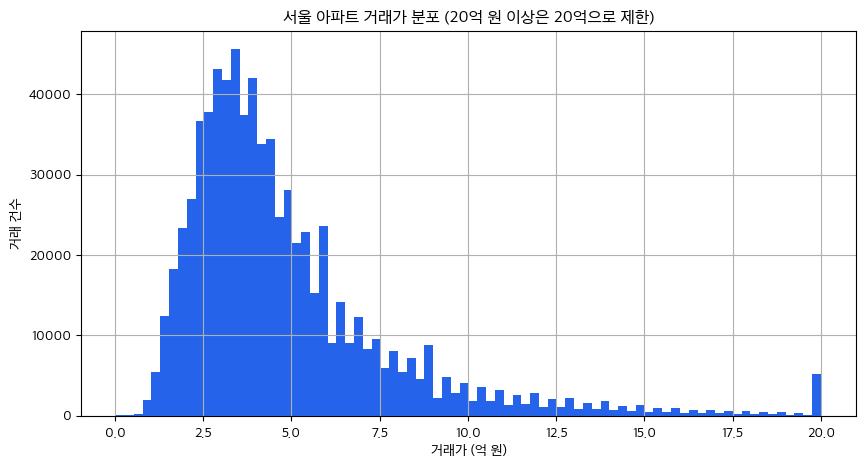

In [5]:
seoul_train["transaction_price_eok"].clip(upper=20).hist(bins=80, color="#2563eb")
plt.title("서울 아파트 거래가 분포 (20억 원 이상은 20억으로 제한)")
plt.xlabel("거래가 (억 원)")
plt.ylabel("거래 건수")
plt.show()

## 6. 평당 단가 분포 보기

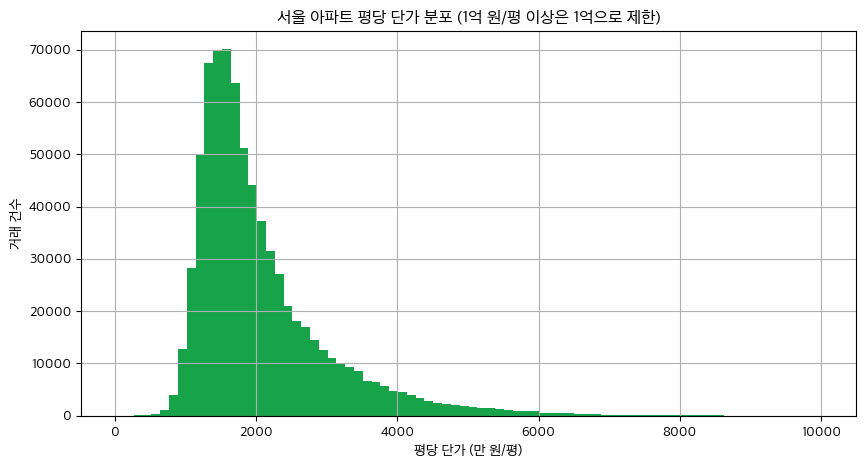

In [6]:
seoul_train["price_per_pyeong_manwon"].clip(upper=10000).hist(bins=80, color="#16a34a")
plt.title("서울 아파트 평당 단가 분포 (1억 원/평 이상은 1억으로 제한)")
plt.xlabel("평당 단가 (만 원/평)")
plt.ylabel("거래 건수")
plt.show()

## 7. 연도별 평당 단가 변화

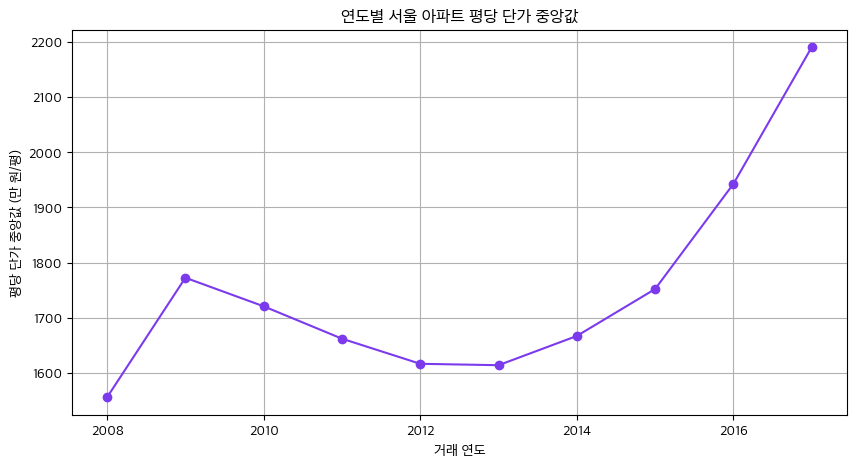

transaction_year
2008    1555.870272
2009    1772.554636
2010    1720.736737
2011    1662.019878
2012    1616.480500
2013    1613.942761
2014    1666.954771
2015    1752.074000
2016    1942.722475
2017    2190.623602
Name: 평당 단가 중앙값_만원, dtype: float64

In [7]:
yearly_price = seoul_train.groupby("transaction_year")["price_per_pyeong_manwon"].median()
yearly_price.plot(marker="o", color="#7c3aed")
plt.title("연도별 서울 아파트 평당 단가 중앙값")
plt.xlabel("거래 연도")
plt.ylabel("평당 단가 중앙값 (만 원/평)")
plt.show()

yearly_price.rename("평당 단가 중앙값_만원")

## 8. 동별 평당 단가 상위 지역

거래 수가 너무 적은 동은 기준으로 쓰기 불안하므로, 거래 1,000건 이상인 동만 본다.

In [8]:
dong_stats = (
    seoul_train.groupby("dong")
    .agg(
        count=("transaction_id", "count"),
        median_price_per_pyeong=("price_per_pyeong", "median"),
        median_price=("transaction_real_price", "median"),
    )
    .query("count >= 1000")
    .sort_values("median_price_per_pyeong", ascending=False)
)

dong_stats.head(20)

,count,median_price_per_pyeong,median_price
dong,,,
개포동,9543,5073.716611,73000.0
압구정동,3295,4502.968530,150000.0
반포동,8093,4273.179153,119000.0
대치동,7569,3972.486938,107500.0
잠실동,10656,3869.841392,97000.0
도곡동,6630,3588.871737,98000.0
신천동,6273,3402.402664,83000.0
삼성동,4299,3307.356403,88000.0
잠원동,8041,3231.186137,82500.0


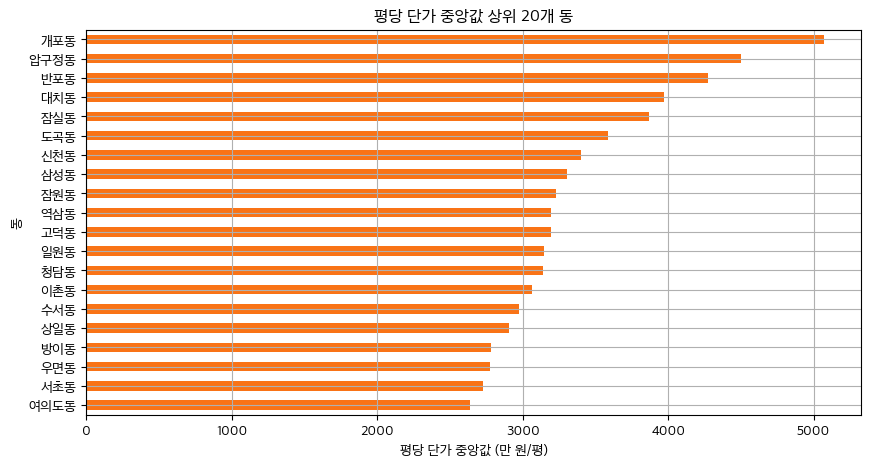

In [9]:
dong_stats.head(20).sort_values("median_price_per_pyeong")["median_price_per_pyeong"].plot(kind="barh", color="#f97316")
plt.title("평당 단가 중앙값 상위 20개 동")
plt.xlabel("평당 단가 중앙값 (만 원/평)")
plt.ylabel("동")
plt.show()

## 9. 기준점 정리

아래 숫자를 기준으로 이후 모델링을 해석한다.

In [10]:
baseline = {
    "서울 데이터 건수": len(seoul_train),
    "거래가 중앙값_만원": seoul_train["transaction_real_price"].median(),
    "거래가 중앙값_억원": seoul_train["transaction_price_eok"].median(),
    "거래가 평균_억원": seoul_train["transaction_price_eok"].mean(),
    "평수 중앙값": seoul_train["pyeong"].median(),
    "평당 단가 중앙값_만원": seoul_train["price_per_pyeong_manwon"].median(),
    "평당 단가 평균_만원": seoul_train["price_per_pyeong_manwon"].mean(),
}

pd.Series(baseline).round(2)

서울 데이터 건수       742285.00
거래가 중앙값_만원       40000.00
거래가 중앙값_억원           4.00
거래가 평균_억원            4.92
평수 중앙값              25.16
평당 단가 중앙값_만원      1770.41
평당 단가 평균_만원       2062.77
dtype: float64

## 10. 머신러닝 실습 목적 정의

### 페르소나

서울 아파트 매수/투자 후보를 빠르게 비교하고 싶은 초보 부동산 분석가.

### 문제 정의

아파트 기본 정보와 거래 시점 정보를 바탕으로 예상 실거래가를 예측하고, 실제 가격 대비 비싼지/저렴한지 판단하는 기준점을 만든다.

### 첫 번째 모델의 목표

- 복잡한 성능 경쟁보다 전체 머신러닝 흐름을 이해한다.
- 서울 데이터만 사용한다.
- 평당 단가와 모델 예측값을 비교하며 해석한다.

## 11. 그래프 해석 메모

아래 메모는 모델링 전에 데이터의 큰 흐름을 말로 설명하기 위한 공간이다.
그래프를 보고 직접 관찰한 내용을 계속 보강한다.


### 11-1. 거래가 분포 해석

- 거래가 단위는 만원이며, 그래프에서는 억 원 단위로 표시한다.
- 중앙값은 약 4억 원, 평균은 약 4.9억 원이다.
- 평균이 중앙값보다 크므로 고가 거래가 평균을 위로 끌어올리는 구조로 볼 수 있다.
- 시각화에서는 20억 원 이상을 20억 원으로 제한해서 전체 분포를 보기 쉽게 만들었다.
- 모델링에서는 고가 거래를 제거할지, 유지할지, 별도 구간으로 볼지 판단이 필요하다.


### 11-2. 평당 단가 분포 해석

- 서울 전체 평당 단가 중앙값은 약 1,770만 원/평이다.
- 평균은 약 2,063만 원/평으로 중앙값보다 높다.
- 일부 고가 지역 또는 특수 거래가 평당 단가 평균을 끌어올릴 수 있다.
- 평당 1억 원/평 이상은 일반적인 기준에서 극단값 후보로 본다.


### 11-3. 연도별 흐름 해석

- 연도별 평당 단가 중앙값은 거래 시점이 가격 예측에 중요하다는 근거가 된다.
- `transaction_year_month`는 단순 날짜 컬럼이 아니라 시장 흐름을 담는 핵심 변수로 볼 수 있다.
- 이후 모델링에서는 연도와 월을 분리하거나, 시간 흐름 변수로 사용할 수 있다.


### 11-4. 동별 차이 해석

- 동별 평당 단가 차이가 크면 `dong`은 중요한 범주형 변수다.
- 단, 거래 수가 적은 동은 중앙값이 불안정할 수 있다.
- 현재는 거래 1,000건 이상인 동만 비교 대상으로 삼았다.


## 12. 이상치 후보 확인

이상치는 무조건 삭제하는 것이 아니라, 먼저 기준을 세우고 확인한다.
수업 실습에서는 설명 가능한 기준을 만드는 것이 중요하다.


In [ ]:
outlier_checks = {
    "20억 초과 거래": (seoul_train["transaction_price_eok"] > 20).sum(),
    "평당 1억 초과": (seoul_train["price_per_pyeong_manwon"] > 10000).sum(),
    "전용면적 10㎡ 미만": (seoul_train["exclusive_use_area"] < 10).sum(),
    "전용면적 250㎡ 초과": (seoul_train["exclusive_use_area"] > 250).sum(),
    "건물 나이 음수": (seoul_train["building_age"] < 0).sum(),
    "층수 0 이하": (seoul_train["floor"] <= 0).sum(),
    "층수 80 초과": (seoul_train["floor"] > 80).sum(),
}

outlier_summary = pd.Series(outlier_checks, name="건수").to_frame()
outlier_summary["비율"] = (outlier_summary["건수"] / len(seoul_train) * 100).round(3)
outlier_summary


### 12-1. 고가 거래 확인

20억 원 초과 거래는 이상치라기보다 고가 주택 시장일 수 있다.
삭제 여부는 모델 목적에 따라 달라진다.


In [ ]:
high_price_samples = (
    seoul_train[seoul_train["transaction_price_eok"] > 20]
    .sort_values("transaction_price_eok", ascending=False)
    [["transaction_year_month", "dong", "apt", "exclusive_use_area", "floor", "transaction_price_eok", "price_per_pyeong_manwon"]]
    .head(20)
)

high_price_samples


### 12-2. 평당 단가 극단값 확인

평당 단가가 과도하게 높은 거래는 작은 면적, 특수 지역, 데이터 오류 가능성을 함께 확인한다.


In [ ]:
high_pyeong_price_samples = (
    seoul_train[seoul_train["price_per_pyeong_manwon"] > 10000]
    .sort_values("price_per_pyeong_manwon", ascending=False)
    [["transaction_year_month", "dong", "apt", "exclusive_use_area", "pyeong", "transaction_price_eok", "price_per_pyeong_manwon"]]
    .head(20)
)

high_pyeong_price_samples


## 13. 전처리 기준 초안

첫 번째 베이스라인 모델에서는 너무 공격적으로 데이터를 삭제하지 않는다.
대신 시각화와 기준표에서 극단값을 따로 표시하고, 모델 성능을 본 뒤 전처리 강도를 조절한다.

| 항목 | 기준 초안 | 처리 방향 |
| --- | --- | --- |
| 거래가 | 20억 원 초과 | 이상치라기보다 고가 시장으로 분리 검토 |
| 평당 단가 | 1억 원/평 초과 | 극단값 후보, 샘플 확인 후 결정 |
| 면적 | 10㎡ 미만 또는 250㎡ 초과 | 데이터 오류/특수 거래 여부 확인 |
| 건물 나이 | 음수 | 거래연도보다 준공연도가 미래인 데이터로 오류 후보 |
| 층수 | 0 이하 또는 80층 초과 | 데이터 정의 확인 필요 |

다음 단계는 이 기준을 바탕으로 `baseline model용 데이터셋`을 만드는 것이다.


## 14. 이상치 정리 결과

첫 번째 베이스라인 모델에서는 설명하기 어려운 오류 후보와 극단값 일부만 정리한다.
20억 원 초과 거래는 고가 시장일 수 있으므로 이번 단계에서는 제거하지 않는다.


In [ ]:
CLEANED_PATH = BASE_DIR / "data" / "processed" / "seoul_train_cleaned_baseline.csv"
REMOVED_PATH = BASE_DIR / "data" / "processed" / "seoul_train_removed_outliers.csv"

seoul_cleaned = pd.read_csv(CLEANED_PATH)
seoul_removed = pd.read_csv(REMOVED_PATH)

cleaning_result = pd.Series({
    "정리 전 서울 데이터": len(seoul_train),
    "정리 후 baseline 데이터": len(seoul_cleaned),
    "제거된 행": len(seoul_removed),
    "제거 비율(%)": round(len(seoul_removed) / len(seoul_train) * 100, 4),
})

cleaning_result


### 14-1. 적용한 정리 기준

| 기준 | 처리 |
| --- | --- |
| 평당 1억 원/평 초과 | 제거 |
| 전용면적 10㎡ 미만 | 제거 |
| 전용면적 250㎡ 초과 | 제거 |
| 건물 나이 음수 | 제거 |
| 층수 0 이하 | 제거 |
| 층수 80층 초과 | 제거 |
| 20억 초과 거래 | 유지, 고가 시장으로 별도 검토 |


In [ ]:
rule_summary = pd.read_csv(BASE_DIR / "reports" / "seoul_cleaning_rule_summary.csv")
rule_summary


### 14-2. 정리 전/후 기준값 비교

데이터 정리로 전체 분포가 크게 바뀌었는지 확인한다.


In [ ]:
compare_cols = [
    "transaction_price_eok",
    "exclusive_use_area",
    "pyeong",
    "price_per_pyeong_manwon",
    "floor",
    "building_age",
]

before = seoul_train[compare_cols].describe().round(2)
after = seoul_cleaned[compare_cols].describe().round(2)

pd.concat({"정리 전": before, "정리 후": after}, axis=1)


## 15. 다음 단계

이제 머신러닝 첫 모델은 `seoul_train_cleaned_baseline.csv`를 기준으로 만든다.

첫 모델 목표:

- 복잡한 최적화보다 전체 머신러닝 흐름 이해
- 수치형 변수만 사용한 아주 단순한 회귀 모델부터 시작
- 이후 `dong`, `apt` 같은 범주형 변수를 추가해서 성능 변화를 비교
